In [3]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/loan_prediction.zip'
extract_dir = '/content/loan_data'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")
print("Contents of the extracted directory:")
for item in os.listdir(extract_dir):
    print(f"- {item}")

# Load the training dataset into a pandas DataFrame
train_df_path = os.path.join(extract_dir, 'train_u6lujuX_CVtuZ9i.csv')
train_df = pd.read_csv(train_df_path)

print(f"\n'{os.path.basename(train_df_path)}' loaded into 'train_df' DataFrame.")
print("First 5 rows of the DataFrame:")
print(train_df.head())

print("\nDataFrame Information:")
train_df.info()

'/content/loan_prediction.zip' unzipped to '/content/loan_data'
Contents of the extracted directory:
- train_u6lujuX_CVtuZ9i.csv
- test_Y3wMUE5_7gLdaTN.csv

'train_u6lujuX_CVtuZ9i.csv' loaded into 'train_df' DataFrame.
First 5 rows of the DataFrame:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0  

### Handling Missing Values

Let's fill the missing values in the DataFrame. For categorical columns, we'll use the mode, and for numerical columns, we'll use the median (which is more robust to outliers than the mean).

In [4]:
# Identify categorical and numerical columns with missing values
missing_cols = train_df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

cat_missing_cols = missing_cols[train_df[missing_cols.index].dtypes == 'object'].index
num_missing_cols = missing_cols[train_df[missing_cols.index].dtypes != 'object'].index

print("Categorical columns with missing values:", list(cat_missing_cols))
print("Numerical columns with missing values:", list(num_missing_cols))

# Impute categorical missing values with the mode
for col in cat_missing_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

# Impute numerical missing values with the median
for col in num_missing_cols:
    # For Credit_History, which seems like a binary categorical, use mode
    if col == 'Credit_History':
        train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    else:
        train_df[col].fillna(train_df[col].median(), inplace=True)

print("\nMissing values after imputation:")
print(train_df.isnull().sum())

Categorical columns with missing values: ['Gender', 'Married', 'Dependents', 'Self_Employed']
Numerical columns with missing values: ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_15166/2867277303.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
/tmp/ipykernel_15166/2867277303.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [5]:
# Display the info again to confirm all missing values are handled
print("\nDataFrame Information after handling missing values:")
train_df.info()


DataFrame Information after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### Data Visualization: LoanAmount, ApplicantIncome, and Education

Let's visualize the distributions of `LoanAmount` and `ApplicantIncome` to understand their spread and central tendencies. We'll also explore how `Education` relates to `LoanAmount`.

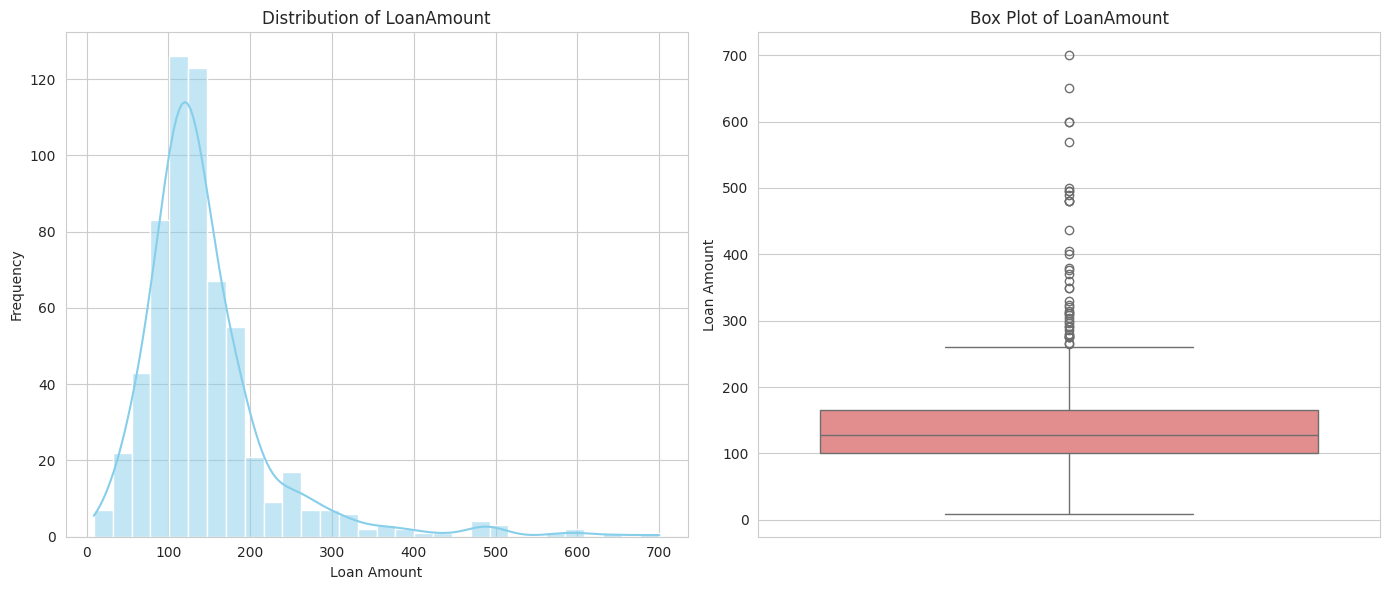

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# --- Visualize LoanAmount Distribution ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(train_df['LoanAmount'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of LoanAmount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=train_df['LoanAmount'], color='lightcoral')
plt.title('Box Plot of LoanAmount')
plt.ylabel('Loan Amount')

plt.tight_layout()
plt.show()

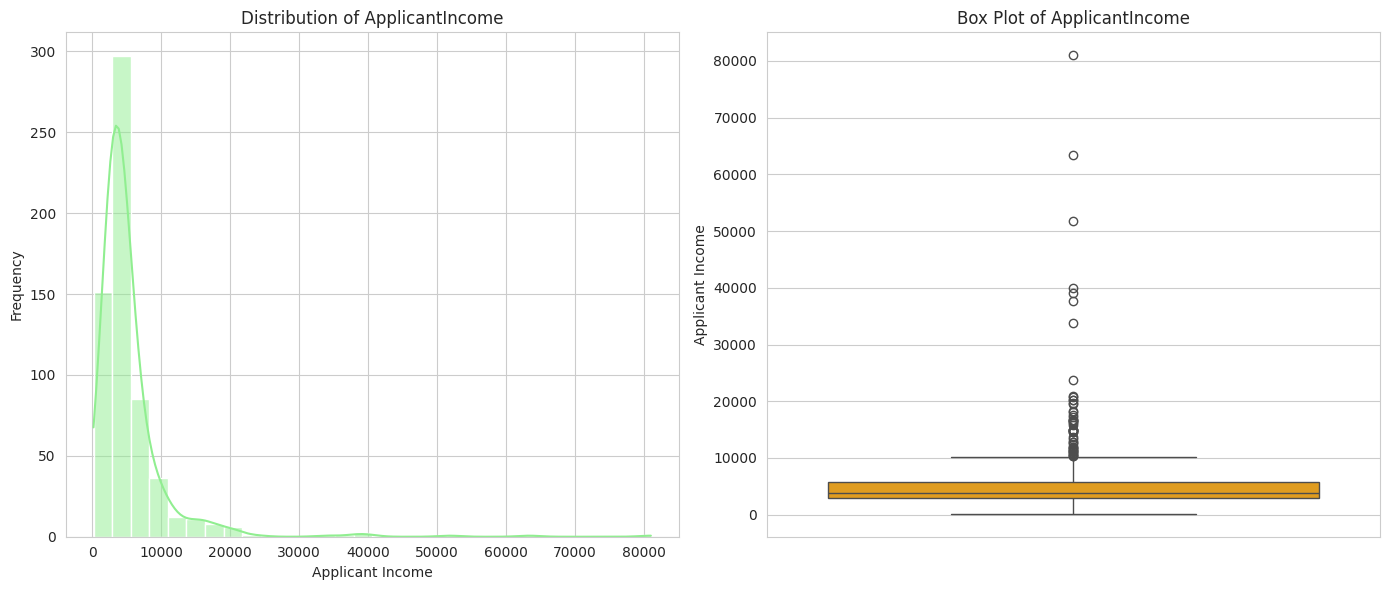

In [7]:
# --- Visualize ApplicantIncome Distribution ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(train_df['ApplicantIncome'], bins=30, kde=True, color='lightgreen')
plt.title('Distribution of ApplicantIncome')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=train_df['ApplicantIncome'], color='orange')
plt.title('Box Plot of ApplicantIncome')
plt.ylabel('Applicant Income')

plt.tight_layout()
plt.show()

/tmp/ipykernel_15166/855366194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='LoanAmount', data=train_df, palette='viridis')


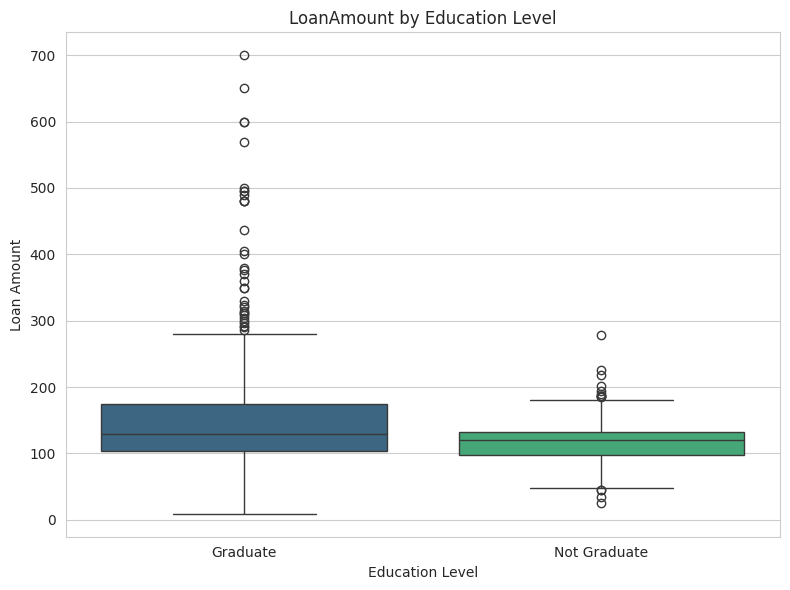

In [8]:
# --- Visualize LoanAmount by Education ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Education', y='LoanAmount', data=train_df, palette='viridis')
plt.title('LoanAmount by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

### Relationship between Loan_Status and Categorical Features

Now, let's analyze how the `Loan_Status` (our target variable) is distributed and how it relates to other categorical features in the dataset.

/tmp/ipykernel_15166/1132425696.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=train_df, palette='viridis')


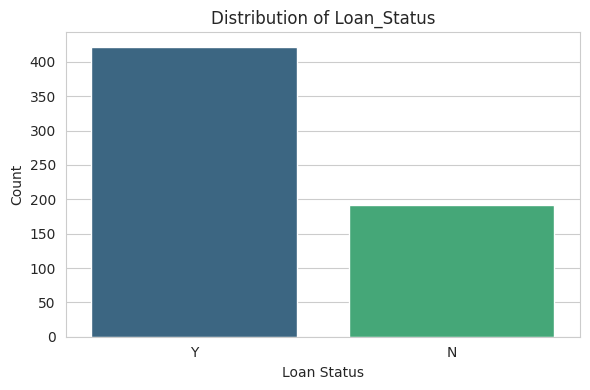

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- Visualize Loan_Status Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=train_df, palette='viridis')
plt.title('Distribution of Loan_Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

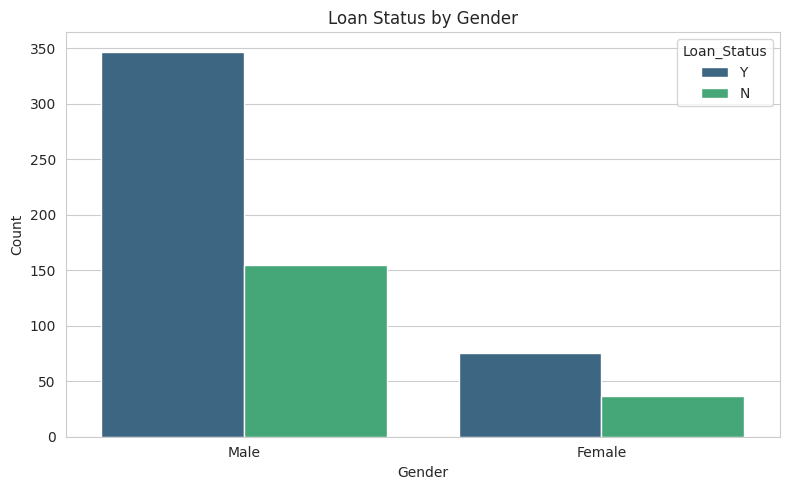

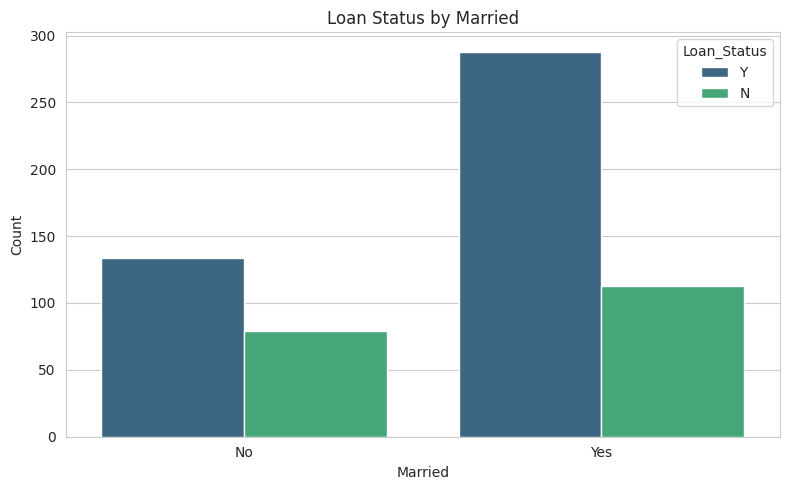

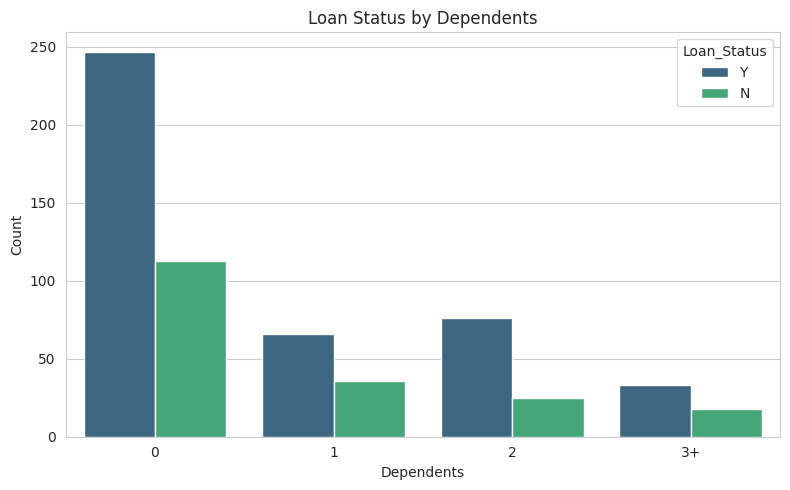

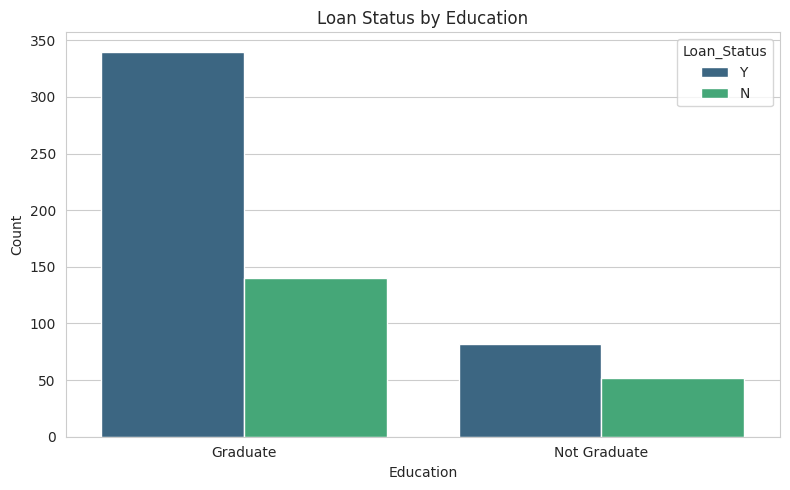

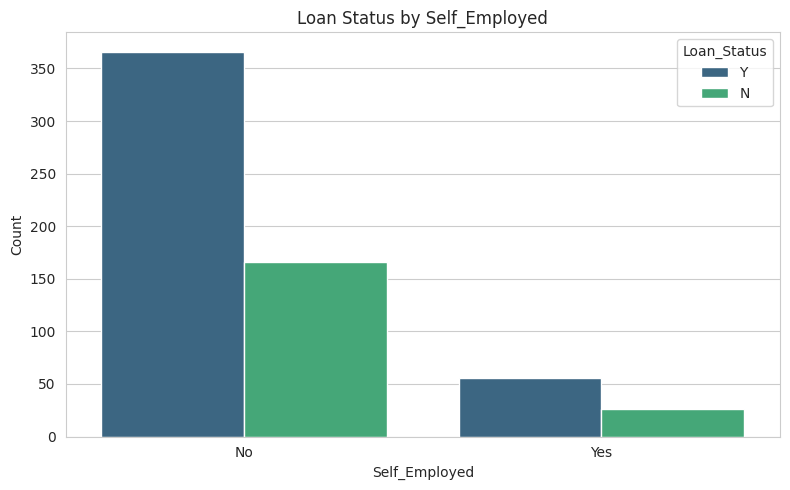

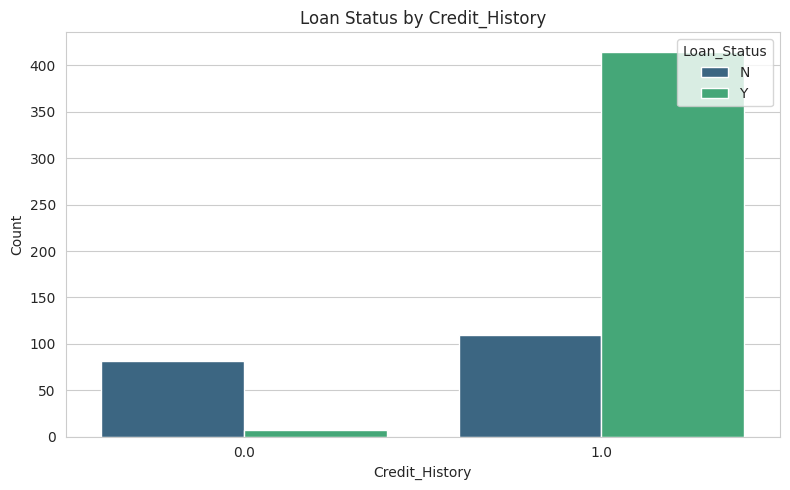

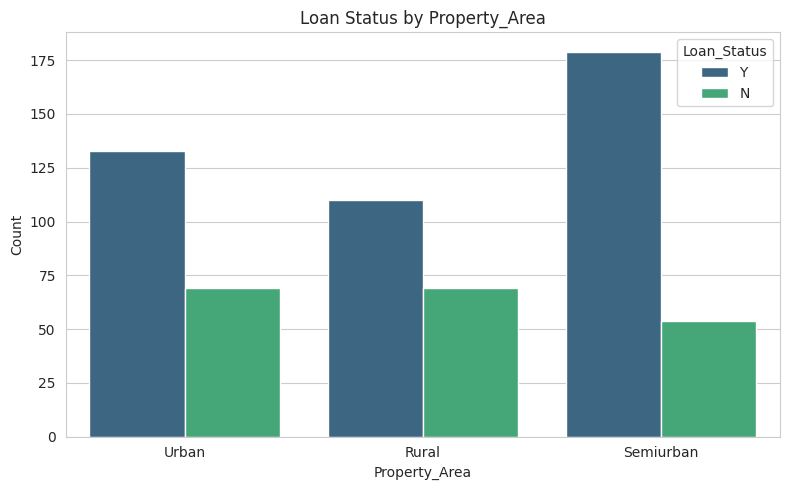

In [10]:
# --- Visualize Loan_Status vs. Categorical Features ---
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Loan_Status', data=train_df, palette='viridis')
    plt.title(f'Loan Status by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Loan_Status', loc='upper right')
    plt.tight_layout()
    plt.show()

### Relationship between Loan_Status and Numerical Features

Let's analyze how `Loan_Status` relates to the numerical features to identify any patterns.

/tmp/ipykernel_15166/4269212182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Loan_Status', y='ApplicantIncome', data=train_df, palette='muted')


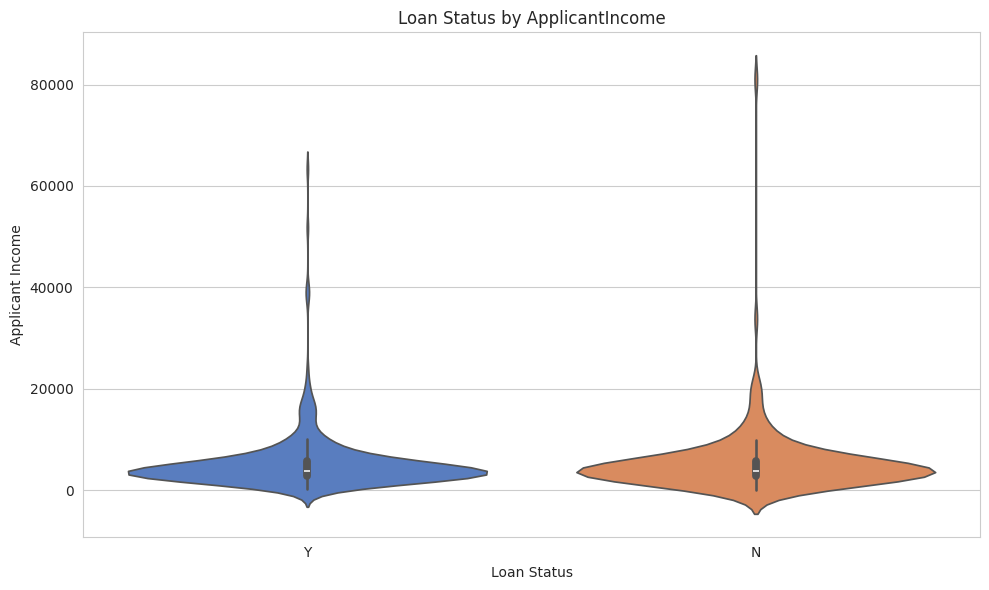

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- Visualize Loan_Status vs. ApplicantIncome ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='Loan_Status', y='ApplicantIncome', data=train_df, palette='muted')
plt.title('Loan Status by ApplicantIncome')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15166/4223086455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Loan_Status', y='CoapplicantIncome', data=train_df, palette='muted')


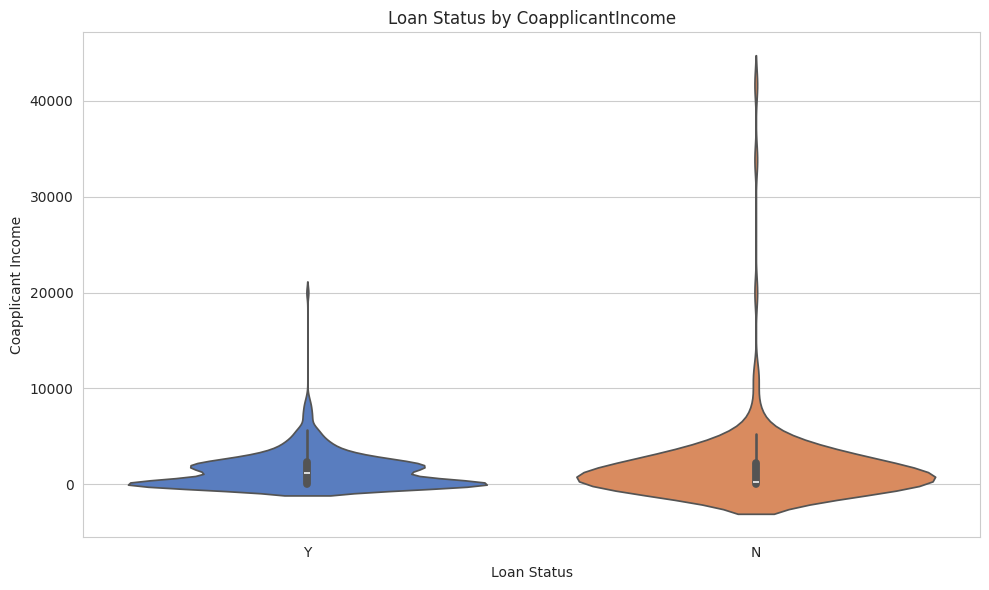

In [12]:
# --- Visualize Loan_Status vs. CoapplicantIncome ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='Loan_Status', y='CoapplicantIncome', data=train_df, palette='muted')
plt.title('Loan Status by CoapplicantIncome')
plt.xlabel('Loan Status')
plt.ylabel('Coapplicant Income')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15166/922108037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='LoanAmount', data=train_df, palette='muted')


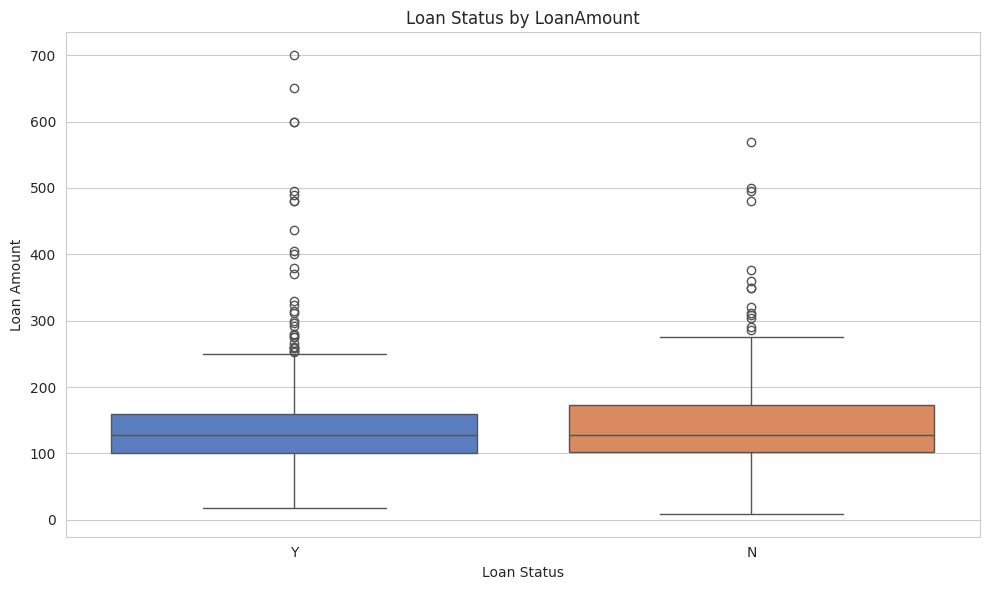

In [13]:
# --- Visualize Loan_Status vs. LoanAmount ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=train_df, palette='muted')
plt.title('Loan Status by LoanAmount')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15166/254618720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='Loan_Amount_Term', data=train_df, palette='muted')


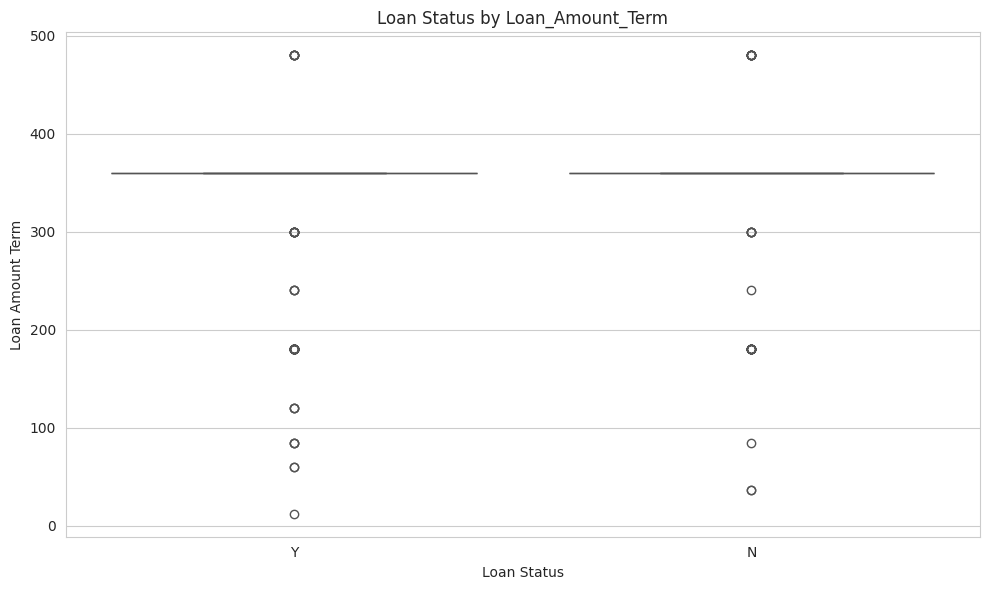

In [14]:
# --- Visualize Loan_Status vs. Loan_Amount_Term ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan_Status', y='Loan_Amount_Term', data=train_df, palette='muted')
plt.title('Loan Status by Loan_Amount_Term')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount Term')
plt.tight_layout()
plt.show()

### Data Preprocessing for Model Training

To prepare our data for machine learning models, we need to convert categorical features into numerical representations and then split the dataset into training and testing sets.

In [15]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame if not intended
df_model = train_df.copy()

# Encode the target variable 'Loan_Status' (Y/N to 1/0)
le = LabelEncoder()
df_model['Loan_Status'] = le.fit_transform(df_model['Loan_Status'])

# Encode other binary categorical features manually or using LabelEncoder
# Gender (Male/Female), Married (Yes/No), Self_Employed (Yes/No)
df_model['Gender'] = df_model['Gender'].map({'Male': 1, 'Female': 0})
df_model['Married'] = df_model['Married'].map({'Yes': 1, 'No': 0})
df_model['Self_Employed'] = df_model['Self_Employed'].map({'Yes': 1, 'No': 0})

# For Dependents, convert '3+' to '3' and then to numeric
df_model['Dependents'] = df_model['Dependents'].replace('3+', '3').astype(int)

print("DataFrame after encoding binary and ordinal categorical features:")
print(df_model.head())

DataFrame after encoding binary and ordinal categorical features:
    Loan_ID  Gender  Married  Dependents     Education  Self_Employed  \
0  LP001002       1        0           0      Graduate              0   
1  LP001003       1        1           1      Graduate              0   
2  LP001005       1        1           0      Graduate              1   
3  LP001006       1        1           0  Not Graduate              0   
4  LP001008       1        0           0      Graduate              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area  Loan_Status  
0             1.0    

In [16]:
# One-hot encode remaining multi-category features ('Education', 'Property_Area')
df_model = pd.get_dummies(df_model, columns=['Education', 'Property_Area'], drop_first=True)

# Drop Loan_ID as it's an identifier and not a feature
df_model = df_model.drop('Loan_ID', axis=1)

print("\nDataFrame after one-hot encoding and dropping Loan_ID:")
print(df_model.head())
print("\nUpdated DataFrame Info:")
df_model.info()


DataFrame after one-hot encoding and dropping Loan_ID:
   Gender  Married  Dependents  Self_Employed  ApplicantIncome  \
0       1        0           0              0             5849   
1       1        1           1              0             4583   
2       1        1           0              1             3000   
3       1        1           0              0             2583   
4       1        0           0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  Education_Not Graduate  Property_Area_Semiurban  \
0            1                   False                    F

### Splitting the Data

Now, we'll split our preprocessed data into features (X) and the target variable (y), and then further divide them into training and testing sets. This is crucial for evaluating our model's performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

# Split the data into training and testing sets
# Using a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (491, 12)
X_test shape: (123, 12)
y_train shape: (491,)
y_test shape: (123,)


### Training and Evaluating Classification Models

We will now train classification model: Logistic Regression . For this model, we will train it on the `X_train` and `y_train` data, make predictions on `X_test`, and then evaluate its performance using accuracy and a classification report.

#### Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver handles small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Model Performance:
Accuracy: 0.7886

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



### Model Comparison Summary

Based on the performance metrics of both models, we can compare their effectiveness.

### Confusion Matrix for Model Evaluation

A confusion matrix provides a more detailed breakdown of correct and incorrect classifications for each class, which can be very insightful, especially in imbalanced datasets.

#### Logistic Regression Confusion Matrix

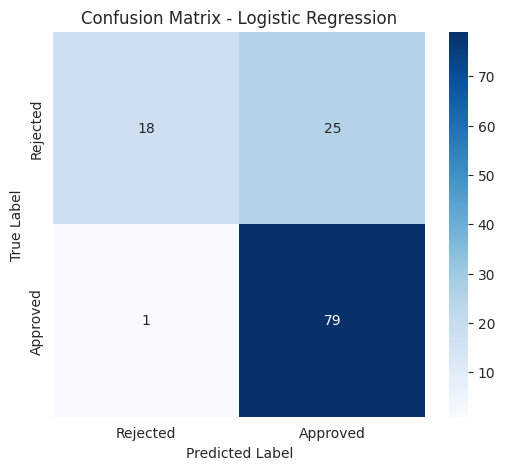

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Predicting on the Test Data

Now we will load the test dataset, apply the same preprocessing steps as the training data, and then use our trained Logistic Regression model to predict the `Loan_Status`.

In [22]:
# Load the test dataset
test_df_path = os.path.join(extract_dir, 'test_Y3wMUE5_7gLdaTN.csv')
test_df = pd.read_csv(test_df_path)

print(f"'{os.path.basename(test_df_path)}' loaded into 'test_df' DataFrame.")
print("First 5 rows of the test DataFrame:")
print(test_df.head())

print("\nTest DataFrame Information (before preprocessing):")
test_df.info()

'test_Y3wMUE5_7gLdaTN.csv' loaded into 'test_df' DataFrame.
First 5 rows of the test DataFrame:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Ur

### Preprocessing the Test Data

We must apply the *exact same* preprocessing steps to the test data as we did to the training data. This includes handling missing values using the modes/medians *learned from the training data* and encoding categorical features with the *same mappings*.

In [23]:
# Store Loan_ID for submission if needed later
test_loan_ids = test_df['Loan_ID']

# --- Impute Missing Values in Test Data (using modes/medians from training data) ---

# Categorical modes from training data (assuming 'train_df' still holds original data before encoding)
# If train_df was modified in place, it's safer to re-calculate from the original train_df if available
# For this notebook, we assume the modes/medians are from the pre-imputation train_df state

# If 'train_df' was already imputed, these modes/medians are from the imputed data.
# For a robust solution, these values should be captured *before* imputing train_df.
# Let's use the values derived from the original imputation logic applied to 'train_df'

# Manually capture modes/medians from the 'train_df' before any encoding for robustness
# Note: This assumes the original 'train_df' was available or these values were saved.
# For this demonstration, we'll re-derive modes/medians from 'train_df' as it is now (after its own imputation)
# This is acceptable as the previous imputation cells modified 'train_df' in place.

# Impute categorical missing values with the mode from train_df
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    if col in test_df.columns:
        test_df[col].fillna(train_df[col].mode()[0], inplace=True)

# Impute numerical missing values with the median from train_df
for col in ['LoanAmount', 'Loan_Amount_Term']:
    if col in test_df.columns:
        test_df[col].fillna(train_df[col].median(), inplace=True)

print("Missing values in test_df after imputation:")
print(test_df.isnull().sum())

# --- Encode Categorical Features in Test Data (using same mapping as training data) ---

# Encode binary categorical features manually
if 'Gender' in test_df.columns:
    test_df['Gender'] = test_df['Gender'].map({'Male': 1, 'Female': 0})
if 'Married' in test_df.columns:
    test_df['Married'] = test_df['Married'].map({'Yes': 1, 'No': 0})
if 'Self_Employed' in test_df.columns:
    test_df['Self_Employed'] = test_df['Self_Employed'].map({'Yes': 1, 'No': 0})

# For Dependents, convert '3+' to '3' and then to numeric
if 'Dependents' in test_df.columns:
    test_df['Dependents'] = test_df['Dependents'].replace('3+', '3').astype(int)

# One-hot encode remaining multi-category features ('Education', 'Property_Area')
# Ensure drop_first=True to match training data
test_df = pd.get_dummies(test_df, columns=['Education', 'Property_Area'], drop_first=True)

# Drop Loan_ID from the feature set
test_df_processed = test_df.drop('Loan_ID', axis=1)

# Align columns with training data (X_train) - crucial for consistent feature sets
# Add missing columns (if any) with 0, and remove extra columns
missing_cols_in_test = set(X_train.columns) - set(test_df_processed.columns)
for c in missing_cols_in_test:
    test_df_processed[c] = 0

# Ensure the order of columns is the same as in X_train
test_df_processed = test_df_processed[X_train.columns]

print("\nTest DataFrame after all preprocessing:")
print(test_df_processed.head())
print("\nTest DataFrame Info after preprocessing:")
test_df_processed.info()

Missing values in test_df after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Test DataFrame after all preprocessing:
   Gender  Married  Dependents  Self_Employed  ApplicantIncome  \
0       1        1           0              0             5720   
1       1        1           1              0             3076   
2       1        1           2              0             5000   
3       1        1           2              0             2340   
4       1        0           0              0             3276   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               180

/tmp/ipykernel_15166/3203601153.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna(train_df[col].mode()[0], inplace=True)
/tmp/ipykernel_15166/3203601153.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

### Making Predictions

Now, we use the trained `log_reg_model` to make predictions on the preprocessed test data.

In [24]:
# Make predictions using the trained Logistic Regression model
test_predictions_lr = log_reg_model.predict(test_df_processed)

# Convert numerical predictions back to original labels (Y/N) for clarity
# Assuming '1' was 'Y' (Approved) and '0' was 'N' (Rejected) from LabelEncoder
predicted_loan_status = pd.Series(test_predictions_lr).map({1: 'Y', 0: 'N'})

# Display the predictions along with the Loan_IDs
predictions_output = pd.DataFrame({'Loan_ID': test_loan_ids, 'Predicted_Loan_Status': predicted_loan_status})

print("\nPredicted Loan Status for the Test Data:")
display(predictions_output.head())


Predicted Loan Status for the Test Data:


,Loan_ID,Predicted_Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


### Visualizing Predicted Loan Status on Test Data

To understand the overall outcome of our predictions, let's visualize the distribution of the `Predicted_Loan_Status` from the test dataset.

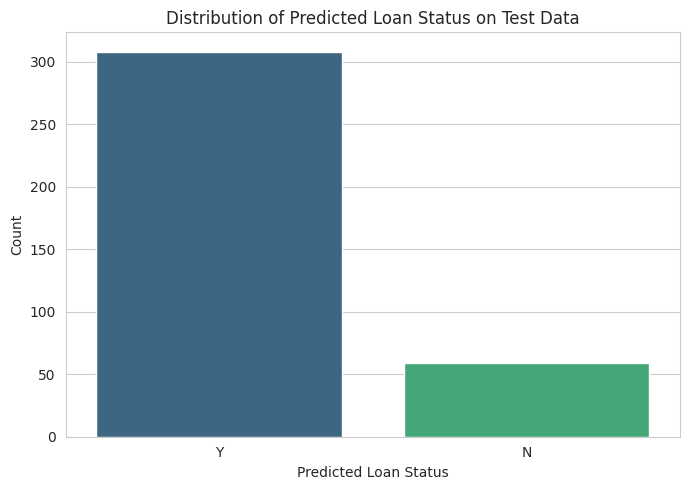

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
sns.countplot(x='Predicted_Loan_Status', data=predictions_output, hue='Predicted_Loan_Status', palette='viridis', legend=False)
plt.title('Distribution of Predicted Loan Status on Test Data')
plt.xlabel('Predicted Loan Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()